# Fake News Detection Using Logistic Regression

**Student ID:** CIT-24-01-0460  
**Model:** Logistic Regression  
**Task:** Fake and Real News Classification

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Identify the project root directory
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Allow the notebook to import Python files from the src folder
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Models folder:", MODELS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: d:\NLP_Group_39
Data folder: d:\NLP_Group_39\data
Models folder: d:\NLP_Group_39\models
Reports folder: d:\NLP_Group_39\reports


In [3]:
from data_loader import load_news_data
from preprocessing import clean_text

print("Project functions imported successfully.")

Project functions imported successfully.


In [4]:
dataset = load_news_data()

print("Dataset loaded successfully.")
print("Dataset shape:", dataset.shape)

dataset.head()

Dataset loaded successfully.
Dataset shape: (39103, 6)


,title,text,subject,date,label,content
0,First Somali Refugee Elected In American Hist...,"On November 8, 2016, Ilhan Omar made history a...",News,"December 8, 2016",0,First Somali Refugee Elected In American Histo...
1,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...,This video should rock every advocate of free...,politics,"Mar 24, 2017",0,MY LAST VIDEO EVER?…Paul Joseph Watson Explain...
2,GOP Third-Party Candidate Live-Tweets Trump’s...,It s only been a few weeks since CIA veteran E...,News,"August 15, 2016",0,GOP Third-Party Candidate Live-Tweets Trump’s ...
3,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...,When four Chicago thugs videotaped the brutal ...,politics,"Dec 9, 2017",0,BREAKING NEWS: Woman Who Narrated BRUTAL TORTU...
4,Iran warns U.S. against imposing further sanct...,BEIRUT/DUBAI (Reuters) - Iran warned the Unite...,worldnews,"October 8, 2017",1,Iran warns U.S. against imposing further sanct...


In [5]:
print("Dataset columns:")
print(dataset.columns.tolist())

print("\nDataset information:")
dataset.info()


Dataset columns:
['title', 'text', 'subject', 'date', 'label', 'content']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 39103 entries, 0 to 39102
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    39103 non-null  str  
 1   text     39103 non-null  str  
 2   subject  39103 non-null  str  
 3   date     39103 non-null  str  
 4   label    39103 non-null  int64
 5   content  39103 non-null  str  
dtypes: int64(1), str(5)
memory usage: 1.8 MB


In [6]:
missing_values = dataset.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64


In [7]:
class_distribution = dataset["label"].value_counts().sort_index()

print("Class distribution:")
print(class_distribution)

print("\nLabel mapping:")
print("0 = Fake News")
print("1 = Real News")

Class distribution:
label
0    17907
1    21196
Name: count, dtype: int64

Label mapping:
0 = Fake News
1 = Real News


## Exploratory Data Analysis

This section examines the class distribution, article lengths, and frequently occurring words in fake and real news articles.

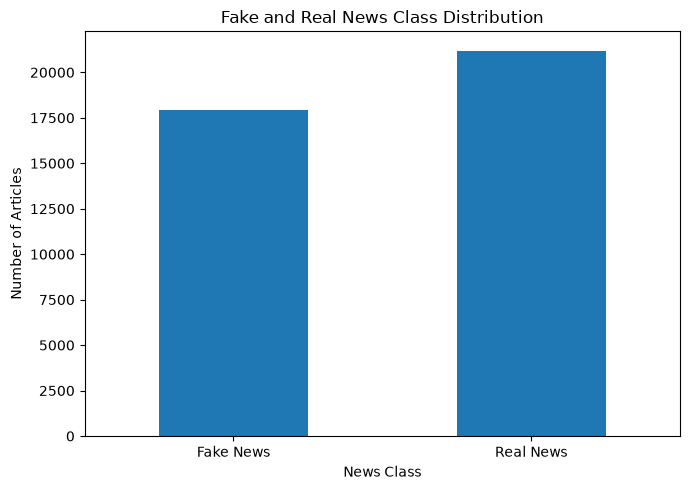

Chart saved to: d:\NLP_Group_39\reports\class_distribution.png


In [8]:
class_names = class_distribution.rename(
    index={
        0: "Fake News",
        1: "Real News"
    }
)

class_names.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Fake and Real News Class Distribution")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()

class_chart_path = REPORTS_DIR / "class_distribution.png"

plt.savefig(
    class_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", class_chart_path)

In [9]:
dataset["word_count"] = (
    dataset["content"]
    .astype(str)
    .str.split()
    .str.len()
)

word_count_summary = (
    dataset.groupby("label")["word_count"]
    .describe()
)

print("Article word count summary:")
display(word_count_summary)

Article word count summary:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,17907.0,428.937790,357.013867,2.0,279.00,385.0,514.0,8148.0
1,21196.0,394.829072,273.771155,4.0,157.75,368.5,533.0,5181.0


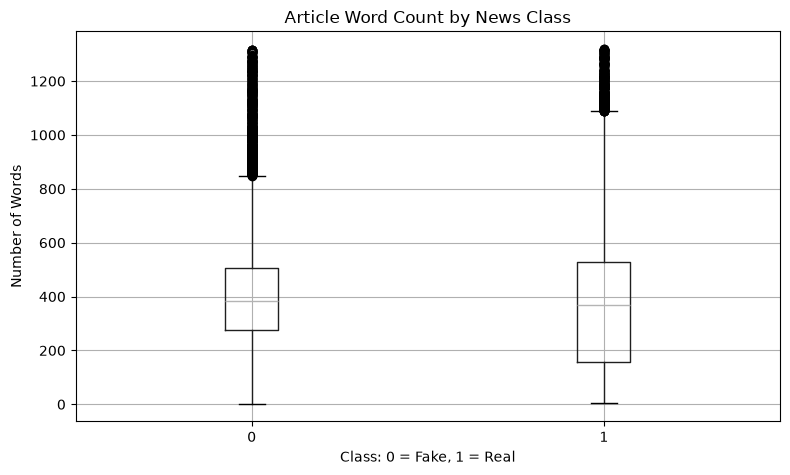

Chart saved to: d:\NLP_Group_39\reports\article_length_distribution.png


In [10]:
word_count_limit = dataset["word_count"].quantile(0.99)

length_plot_data = dataset[
    dataset["word_count"] <= word_count_limit
].copy()

length_plot_data.boxplot(
    column="word_count",
    by="label",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Article Word Count by News Class")
plt.xlabel("Class: 0 = Fake, 1 = Real")
plt.ylabel("Number of Words")
plt.tight_layout()

length_chart_path = REPORTS_DIR / "article_length_distribution.png"

plt.savefig(
    length_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", length_chart_path)

In [11]:
from sklearn.feature_extraction.text import CountVectorizer


def get_top_words(text_data, number_of_words=15):
    sample_size = min(5000, len(text_data))

    sampled_text = text_data.sample(
        n=sample_size,
        random_state=42
    )

    vectorizer = CountVectorizer(
        preprocessor=clean_text,
        lowercase=False,
        stop_words="english",
        max_features=5000
    )

    word_matrix = vectorizer.fit_transform(
        sampled_text.astype(str)
    )

    frequencies = word_matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    frequency_table = pd.DataFrame(
        {
            "word": words,
            "frequency": frequencies
        }
    )

    return (
        frequency_table
        .sort_values("frequency", ascending=False)
        .head(number_of_words)
        .reset_index(drop=True)
    )


fake_top_words = get_top_words(
    dataset.loc[dataset["label"] == 0, "content"]
)

print("Most frequent words in Fake News:")
display(fake_top_words)

Most frequent words in Fake News:


,word,frequency
0,trump,20970
1,said,6979
2,president,6164
3,people,6015
4,just,5014
5,obama,4458
6,donald,4431
7,clinton,4119
8,like,4066
9,video,3626


In [12]:
real_top_words = get_top_words(
    dataset.loc[dataset["label"] == 1, "content"]
)

print("Most frequent words in Real News:")
display(real_top_words)

Most frequent words in Real News:


,word,frequency
0,said,23014
1,trump,13707
2,reuters,6715
3,president,6675
4,state,5087
5,government,4412
6,house,4350
7,new,4183
8,states,3982
9,republican,3949


In [13]:
sample_text = dataset.loc[0, "content"]

cleaned_sample = clean_text(sample_text)

print("Original text:")
print(sample_text[:500])

print("\nCleaned text:")
print(cleaned_sample[:500])

Original text:
First Somali Refugee Elected In American History Subjected To Islamophobic Attack On November 8, 2016, Ilhan Omar made history as being the first Somali-American to be elected to any position in America. Hailing from the progressive state of Minnesota, Omar will serve in the state House of Representatives from the 60B district. Running on the Democratic-Farmer-Labor Party, Omar supports progressive causes championed by Hillary Clinton and Bernie Sanders, Omar won with 81 percent of the vote.The 

Cleaned text:
first somali refugee elected in american history subjected to islamophobic attack on november ilhan omar made history as being the first somali american to be elected to any position in america hailing from the progressive state of minnesota omar will serve in the state house of representatives from the b district running on the democratic farmer labor party omar supports progressive causes championed by hillary clinton and bernie sanders omar won with percent of t

## Feature Engineering Using TF-IDF

TF-IDF converts cleaned news text into numerical feature vectors.  
Unigrams and bigrams are used to capture individual words and short word sequences.

In [14]:
# Select the news text as the input feature
X = dataset["content"].astype(str)

# Select the class label as the target
y = dataset["label"].astype(int)

print("Number of input records:", len(X))
print("Number of target labels:", len(y))

print("\nTarget class distribution:")
print(y.value_counts().sort_index())

Number of input records: 39103
Number of target labels: 39103

Target class distribution:
label
0    17907
1    21196
Name: count, dtype: int64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

print("\nTraining records:", len(X_train))
print("Testing records :", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Train-test split completed successfully.

Training records: 31282
Testing records : 7821

Training class distribution:
label
0    14325
1    16957
Name: count, dtype: int64

Testing class distribution:
label
0    3582
1    4239
Name: count, dtype: int64


In [16]:
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=clean_text,
    lowercase=False,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=50000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created successfully.")

TF-IDF vectorizer created successfully.


In [17]:
print("Starting TF-IDF feature extraction...")

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF feature extraction completed.")

print("\nTraining feature shape:", X_train_tfidf.shape)
print("Testing feature shape :", X_test_tfidf.shape)

print(
    "Vocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

Starting TF-IDF feature extraction...
TF-IDF feature extraction completed.

Training feature shape: (31282, 50000)
Testing feature shape : (7821, 50000)
Vocabulary size: 50000


In [18]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 20 TF-IDF features:")
print(feature_names[:20])

print("\nLast 20 TF-IDF features:")
print(feature_names[-20:])

First 20 TF-IDF features:
['aa' 'aapl' 'aaron' 'aaron bernstein' 'aarp' 'ab' 'aba' 'ababa' 'aback'
 'abadi' 'abadi office' 'abadi said' 'abandon' 'abandon nuclear'
 'abandoned' 'abandoning' 'abandonment' 'abbas' 'abbas said' 'abbasi']

Last 20 TF-IDF features:
['zippers' 'zone' 'zone budget' 'zone finance' 'zone listen' 'zone syria'
 'zones' 'zones syria' 'zoo' 'zoomph' 'zor' 'zor city' 'zor province'
 'zucker' 'zuckerberg' 'zuckerberg said' 'zuma' 'zuma said' 'zurich'
 'zurich reuters']


## Logistic Regression Model Development

Logistic Regression is used as the machine learning classifier because it is suitable for binary classification and performs effectively with high-dimensional TF-IDF text features.

In [19]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [20]:
print("Logistic Regression model training started...")

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression model training completed successfully.")

Logistic Regression model training started...
Logistic Regression model training completed successfully.


In [21]:
y_pred = logistic_model.predict(X_test_tfidf)

y_probability = logistic_model.predict_proba(
    X_test_tfidf
)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test.iloc[:10].to_numpy())

Predictions generated successfully.

First 10 predicted labels:
[0 1 1 1 1 1 0 1 0 1]

First 10 actual labels:
[0 0 1 1 1 1 0 1 0 1]


In [22]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Logistic Regression Evaluation Results")
print("=" * 45)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Logistic Regression Evaluation Results
Accuracy  : 0.9923
Precision : 0.9901
Recall    : 0.9958
F1-Score  : 0.9929
ROC-AUC   : 0.9995


## Classification Report

The classification report presents precision, recall, F1-score, and support for both fake news and real news classes.

In [23]:
classification_results = classification_report(
    y_test,
    y_pred,
    target_names=["Fake News", "Real News"],
    zero_division=0
)

print("Logistic Regression Classification Report")
print("=" * 55)
print(classification_results)

Logistic Regression Classification Report
              precision    recall  f1-score   support

   Fake News       0.99      0.99      0.99      3582
   Real News       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



## Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified fake and real news articles.

In [24]:
confusion_values = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(confusion_values)

true_fake = confusion_values[0, 0]
false_real = confusion_values[0, 1]
false_fake = confusion_values[1, 0]
true_real = confusion_values[1, 1]

print("\nConfusion Matrix Explanation")
print("=" * 40)
print("Fake news correctly predicted as Fake :", true_fake)
print("Fake news incorrectly predicted as Real:", false_real)
print("Real news incorrectly predicted as Fake:", false_fake)
print("Real news correctly predicted as Real  :", true_real)

Confusion Matrix:
[[3540   42]
 [  18 4221]]

Confusion Matrix Explanation
Fake news correctly predicted as Fake : 3540
Fake news incorrectly predicted as Real: 42
Real news incorrectly predicted as Fake: 18
Real news correctly predicted as Real  : 4221


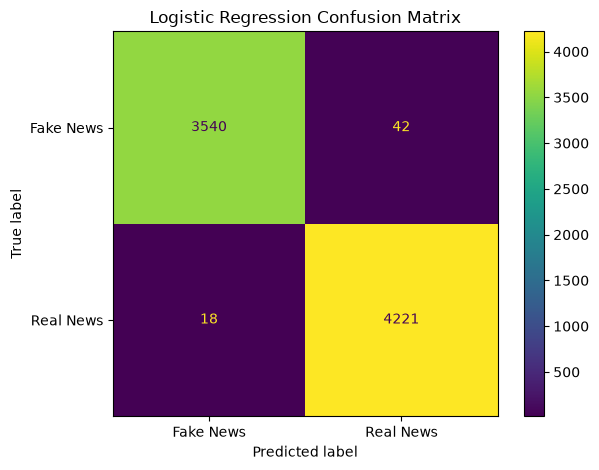

Confusion matrix saved to:
d:\NLP_Group_39\reports\logistic_regression_confusion_matrix.png


In [25]:
matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_values,
    display_labels=["Fake News", "Real News"]
)

matrix_display.plot(
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = (
    REPORTS_DIR
    / "logistic_regression_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:")
print(confusion_matrix_path)

In [26]:
from sklearn.metrics import roc_curve

## ROC Curve

The Receiver Operating Characteristic curve evaluates the model across different classification thresholds. A ROC-AUC score closer to 1 indicates stronger classification performance.

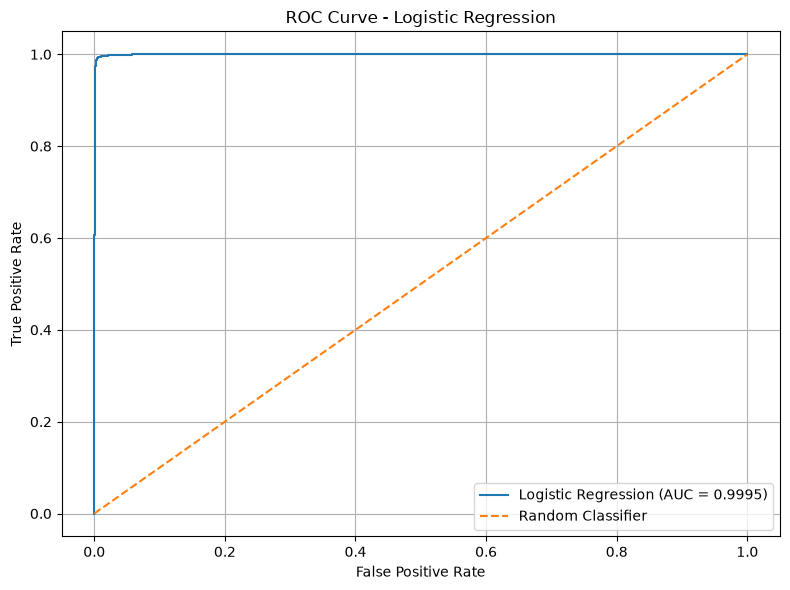

ROC curve saved to:
d:\NLP_Group_39\reports\logistic_regression_roc_curve.png


In [27]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()

roc_curve_path = (
    REPORTS_DIR
    / "logistic_regression_roc_curve.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve saved to:")
print(roc_curve_path)

In [28]:
metrics_dataframe = pd.DataFrame(
    {
        "Model": ["Logistic Regression"],
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1-Score": [f1],
        "ROC-AUC": [roc_auc]
    }
)

metrics_path = (
    REPORTS_DIR
    / "logistic_regression_metrics.csv"
)

metrics_dataframe.to_csv(
    metrics_path,
    index=False
)

print("Evaluation metrics saved successfully.")

display(metrics_dataframe)

print("\nMetrics file:")
print(metrics_path)

Evaluation metrics saved successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.992328,0.990148,0.995754,0.992943,0.99952



Metrics file:
d:\NLP_Group_39\reports\logistic_regression_metrics.csv


In [29]:
prediction_results = pd.DataFrame(
    {
        "News_Text": X_test.to_numpy(),
        "Actual_Label": y_test.to_numpy(),
        "Predicted_Label": y_pred,
        "Real_News_Probability": y_probability,
        "Fake_News_Probability": 1 - y_probability
    }
)

predictions_path = (
    REPORTS_DIR
    / "logistic_regression_test_predictions.csv"
)

prediction_results.to_csv(
    predictions_path,
    index=False
)

print("Test predictions saved successfully.")
print("Number of saved predictions:", len(prediction_results))

display(prediction_results.head())

print("\nPredictions file:")
print(predictions_path)

Test predictions saved successfully.
Number of saved predictions: 7821


,News_Text,Actual_Label,Predicted_Label,Real_News_Probability,Fake_News_Probability
0,JOE BIDEN’S SON BEAU DIES AT AGE 46 Beau Biden...,0,0,0.386529,0.613471
1,THE LIST OF WHO’S WHO TAKING ADVANTAGE OF FAIL...,0,1,0.599112,0.400888
2,"Russia's Lavrov, Tillerson to meet at U.N. Gen...",1,1,0.967941,0.032059
3,Trump's son Donald Trump Jr. to meet with Hous...,1,1,0.989346,0.010654
4,Gay activists march through Serb capital behin...,1,1,0.951037,0.048963



Predictions file:
d:\NLP_Group_39\reports\logistic_regression_test_predictions.csv


## Saving the Trained Model

The trained Logistic Regression model and TF-IDF vectorizer are saved so that they can be reused for predictions on new unseen news articles.

In [30]:
model_path = (
    MODELS_DIR
    / "logistic_regression_model.joblib"
)

vectorizer_path = (
    MODELS_DIR
    / "logistic_regression_tfidf_vectorizer.joblib"
)

joblib.dump(
    logistic_model,
    model_path
)

joblib.dump(
    tfidf_vectorizer,
    vectorizer_path
)

print("Model and TF-IDF vectorizer saved successfully.")

print("\nModel path:")
print(model_path)

print("\nVectorizer path:")
print(vectorizer_path)

Model and TF-IDF vectorizer saved successfully.

Model path:
d:\NLP_Group_39\models\logistic_regression_model.joblib

Vectorizer path:
d:\NLP_Group_39\models\logistic_regression_tfidf_vectorizer.joblib


In [31]:
def predict_new_news(news_text):
    """
    Predict whether a new news article is fake or real.
    """

    if not isinstance(news_text, str):
        raise TypeError("News text must be a string.")

    if not news_text.strip():
        raise ValueError("News text cannot be empty.")

    news_tfidf = tfidf_vectorizer.transform(
        [news_text]
    )

    predicted_label = logistic_model.predict(
        news_tfidf
    )[0]

    class_probabilities = logistic_model.predict_proba(
        news_tfidf
    )[0]

    fake_probability = class_probabilities[0]
    real_probability = class_probabilities[1]

    predicted_class = (
        "REAL NEWS"
        if predicted_label == 1
        else "FAKE NEWS"
    )

    confidence = max(
        fake_probability,
        real_probability
    )

    result = {
        "Prediction": predicted_class,
        "Confidence": confidence,
        "Fake Probability": fake_probability,
        "Real Probability": real_probability
    }

    return result


print("Prediction function created successfully.")

Prediction function created successfully.


In [32]:
sample_new_news = """
The government announced a new public education programme
that will provide additional learning resources for students
in rural schools.
"""

prediction = predict_new_news(
    sample_new_news
)

print("New News Prediction")
print("=" * 40)

print("Prediction       :", prediction["Prediction"])
print(
    "Confidence       :",
    f'{prediction["Confidence"] * 100:.2f}%'
)
print(
    "Fake Probability :",
    f'{prediction["Fake Probability"] * 100:.2f}%'
)
print(
    "Real Probability :",
    f'{prediction["Real Probability"] * 100:.2f}%'
)

New News Prediction
Prediction       : FAKE NEWS
Confidence       : 62.32%
Fake Probability : 62.32%
Real Probability : 37.68%


## Logistic Regression Evaluation Conclusion

The Logistic Regression model achieved strong performance in classifying fake and real news articles.

- Accuracy: 99.23%
- Precision: 99.01%
- Recall: 99.58%
- F1-Score: 99.29%
- ROC-AUC: 99.95%

The high precision and recall values indicate that the model correctly identifies most fake and real news articles in the test dataset. However, the model may learn dataset-specific writing patterns or publisher-related information. Therefore, its performance on completely different news sources, local Sri Lankan news, and other languages may be lower.